# BCO-DMO data

 BCO-DMO states that not all their data is on ERDDAP. Additionally, the chlorophyll data on their ERDDAP server does not have a consistant variable name. So, 'chlorophyll' was searched on the ERDDAP website manually and urls that had chlorophyll data (that was not in-vivo) was processed. The second way of gathering data on this repository was going through the BCO-DMO website itself and manually downloading all projects that collected chorophyll data not on ERRDAP. Finally, ECOHAB was searched and all relevant files were downloaded and formatted. 

To summarize the 3 methods used:
1. Chlorophyll searched on BCO-DMO ERDDAP
2. Chlorophyll searched on the BCO-DMO website
3. ECOHAB searched on the website

Due to the fragmented structure of BCO-DMO, this chlorophyll dataset is most likely not a comprehensive list of all chlorophyll data on BCO-DMO, but is hopefully a good compilation of data. 

## HPLC and Triplicate Flags 
HPLC flags for all projects was found by researching the project's information on chlorophyll sampling

Triplicate flags were decided based off the same methods as detecting SeaBASS flags. 

## ERDDAP files 

In [1]:
url='https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_816216.nc?Station%2Ctime%2Clatitude%2Clongitude%2Cdepth%2CChl_a&Bottom_Depth%3C=100'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url)
da1= da.to_dataframe()
da1 = da1.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','Chl_a':'chl'}) 
da1['source']='BCO-DMO'
da1['project'] = da.projects_0_name
da1['contact']=da.people_0_person_name
da1['affiliation']=da.people_0_affiliation 
da1['chl']=da1['chl']*0.001 #convert nanograms/L to miligram/m^3
da1['url']= 'https://www.bco-dmo.org/dataset/816216' #'https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_816216.html'
da1['HPLC'] = 0 #HPLC based on the url website
counts_series = da1[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
da1['triplicate'] = 1 #based on inpsecting counts_series, no triplicates

url='https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_3884.nc?latitude%2Clongitude%2Ctime%2Cdepth%2Cchl_a'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url) 
da2= da.to_dataframe()
da2 = da2.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','Chl_a':'chl'}) 
da2['source']='BCO-DMO'
da2['project'] = da.projects_0_name
da2['contact']=da.people_0_person_name
da2['affiliation']=da.people_0_affiliation 
da2['url']='https://www.bco-dmo.org/dataset/3884'
da2['HPLC'] = 0 #HPLC based on the url website
#triplicate flag
counts_series = da2[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
da2 = pd.merge(da2, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe

#sometimes, triplicate specific times are recorded (ex: 3:00, 3:05, 3:10 ), so also check for unique datehour entries
da2['date_hour'] = da2['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = da2[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
da2 = pd.merge(da2, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
da2['triplicate'] = 1 #assume bad unless otherwise said
da2.loc[da2['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
da2.loc[(da2['freq_uniq'] == 1) &(da2['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime and 3 unique date_hours, assume triplicate
da2=da2[['lat', 'lon', 'datetime', 'depth', 'chl_a', 'source', 'project','contact', 'affiliation', 'url', 'HPLC', 'triplicate']]

url='https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_929873_v1.nc?Cruise_ID%2Ctime%2Clatitude%2Clongitude%2Cdepth%2CChl_a'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url)
da3= da.to_dataframe()
da3 = da3.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','Chl_a':'chl'}) 
da3['source']='BCO-DMO'
da3['project'] = 'Collaborative Research: Seasonal Variability in refractory dissolved organic carbon fluxes associated with primary marine aerosol emitted from the oceans'
da3['contact']='David J. Kieber'
da3['affiliation']='State University of New York College of Environmental Science and Forestry'
da3['url']='https://www.bco-dmo.org/dataset/929873'#
da3['HPLC'] = 1 #no HPLC based on their url website
counts_series = da3[['depth','datetime','lat','lon']].value_counts()
da3['triplicate'] = 1 #no triplicates
da3=da3[['datetime', 'lat', 'lon', 'depth', 'chl', 'source','project', 'contact', 'affiliation', 'url', 'HPLC', 'triplicate']]

url='https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_906562_v2.nc?time%2CChlA%2Clatitude%2Clongitude'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url) 
da5= da.to_dataframe()
da5 = da5.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','ChlA':'chl'}) 
da5['source']='BCO-DMO'
da5['project'] = 'Collaborative research: Characterization of Synechococcus-cyanophage interactions across phylogenetic and temporal scales'
da5['contact']='Nathan Ahlgren'
da5['affiliation']='Clark University'
da5['url']='https://osprey.bco-dmo.org/dataset/906562'
da5['HPLC'] = 1 #HPLC NO 
counts_series = da5[['datetime','lat','lon']].value_counts()
da5['triplicate'] = 1 #no triplicates

url='https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_765327.nc?latitude%2Clongitude%2Ctime%2Cdepth%2CChlorophyll'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url) 
da6= da.to_dataframe()
da6 = da6.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','Chlorophyll':'chl'}) 
da6['source']='BCO-DMO'
da6['project'] = da.projects_0_name
da6['contact']=da.people_0_person_name
da6['affiliation']=da.people_0_affiliation 
da6['url']='https://www.bco-dmo.org/dataset/765327'
da6['HPLC'] = 1 #HPLC NO 
counts_series = da6[['depth','datetime','lat','lon']].value_counts()
da6['triplicate'] = 1 #no triplicates

url='https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_817214.nc?latitude%2Clongitude%2CChlorophyll%2Ctime'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url)
da7= da.to_dataframe()
da7 = da7.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','Chlorophyll':'chl'}) 
da7['source']='BCO-DMO'
da7['project'] = da.projects_0_name
da7['contact']=da.people_0_person_name
da7['affiliation']=da.people_0_affiliation 
da7['url']='https://www.bco-dmo.org/dataset/817214'
da7['HPLC'] = 1 #HPLC NO 
counts_series = da7[['datetime','lat','lon']].value_counts()
da7['triplicate'] = 1 #no triplicates

url='https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_787316.nc?latitude%2Clongitude%2Cdepth%2CChlorophyll%2Ctime'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url)
da8= da.to_dataframe()
da8 = da8.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','Chlorophyll':'chl'}) 
da8['source']='BCO-DMO'
da8['project'] = da.projects_0_name
da8['contact']=da.people_0_person_name
da8['affiliation']=da.people_0_affiliation 
da8['url']='https://www.bco-dmo.org/dataset/787316'
da8['HPLC'] = 1 #HPLC NO 
counts_series = da8[['depth','datetime','lat','lon']].value_counts()
da8['triplicate'] = 1 #no triplicates

dfs1=[da1,da2,da3,da5,da6,da7,da8] #concatinate all errdap data together
bco1=pd.concat(dfs1).reset_index(drop=True)

NameError: name 'requests' is not defined

## Downloaded files

These files are the ones downloaded from manually inspecting the BCO-DMO website, not the ERDDAP

In [ ]:
rise1 = pd.read_excel(r'BCO-DMO\ProfilePP.xlsx')
rise1['Time'] = [f"{int(t):06d}" for t in rise1['Time']]  #leading 0s removed from time, so pad with 0s until 6 integers long
rise1['Date'] = rise1['Date'].astype(str)
#for month, day, year, hour, min, second, pull out the specific values from Date and Time and create datetime
rise1['month'] = [int(t[4:6]) for t in rise1['Date']] 
rise1['day'] = [int(t[6:8]) for t in rise1['Date']]
rise1['year'] = [int(t[0:4]) for t in rise1['Date']]
rise1['hour'] = [int(t[:2]) for t in rise1['Time']]
rise1['minute'] = [int(t[2:4]) for t in rise1['Time']]
rise1['second'] = [int(t[4:]) for t in rise1['Time']]
rise1['datetime']= pd.to_datetime(rise1[['year', 'month', 'day', 'hour', 'minute', 'second']]) #datetime variable
rise1=rise1.rename(columns={'Lat':'lat','Lon':'lon','depS':'depth','CHL':'chl'})
rise1 = rise1[['datetime','lat', 'lon', 'depth','Cruise', 'Station', 'chl']]
rise1['project']='RISE'
rise1['source']='BCO-DMO'
rise1['contact']='Raphael M. Kudela'
rise1['affiliation']='University of California-Santa Cruz'
rise1['url']='https://www.bco-dmo.org/dataset/3248'
rise1['HPLC'] = 1 #no HPLC

#triplicate flag
counts_series = rise1[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
rise1 = pd.merge(rise1, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe
rise1['date_hour'] = rise1['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = rise1[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
rise1 = pd.merge(rise1, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
rise1['triplicate'] = 1 #assume bad unless otherwise said
rise1.loc[rise1['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
rise1.loc[(rise1['freq_uniq'] == 1) &(rise1['freq_hour'] == 3), 'triplicate'] = 0
rise1=rise1[['datetime', 'lat', 'lon', 'depth', 'Cruise', 'Station', 'chl','project', 'affiliation','source', 'contact', 'url', 'HPLC',  'triplicate']]


rise2 = pd.read_excel(r'BCO-DMO\SurfacePP.xlsx')
rise2['Time'] = [f"{int(t):06d}" for t in rise2['Time']]
rise2['Date'] = rise2['Date'].astype(str)
rise2['month'] = [int(t[4:6]) for t in rise2['Date']]
rise2['day'] = [int(t[6:8]) for t in rise2['Date']]
rise2['year'] = [int(t[0:4]) for t in rise2['Date']]
rise2['hour'] = [int(t[:2]) for t in rise2['Time']]
rise2['minute'] = [int(t[2:4]) for t in rise2['Time']]
rise2['second'] = [int(t[4:]) for t in rise2['Time']]
rise2['datetime']= pd.to_datetime(rise2[['year', 'month', 'day', 'hour', 'minute', 'second']]) #datetime variable
rise2=rise2.rename(columns={'Lat':'lat','Lon':'lon','depS':'depth','Surface_CHL':'chl'})
rise2 = rise2[['datetime','lat', 'lon', 'depth','Cruise', 'Station', 'chl']]
rise2['project']='RISE'
rise2['source']='BCO-DMO'
rise2['contact']='Raphael M. Kudela'
rise2['affiliation']='University of California-Santa Cruz'
rise2['url']='https://www.bco-dmo.org/dataset/3249'
rise2['HPLC'] = 1 #no HPLC 
counts_series = rise2[['depth','datetime','lat','lon']].value_counts() #count how many unique depth, datetime, lat, and lons there are
rise2['triplicate'] = 1 #not triplicate 


#next cruise
rise3 = pd.read_excel(r'BCO-DMO\AllBottle.xlsx')
rise3['Time'] = [f"{int(t):06d}" for t in rise3['Time']]
rise3['Date'] = rise3['Date'].astype(str)
rise3['month'] = [int(t[4:6]) for t in rise3['Date']]
rise3['day'] = [int(t[6:8]) for t in rise3['Date']]
rise3['year'] = [int(t[0:4]) for t in rise3['Date']]
rise3['hour'] = [int(t[:2]) for t in rise3['Time']]
rise3['minute'] = [int(t[2:4]) for t in rise3['Time']]
rise3['second'] = [int(t[4:]) for t in rise3['Time']]
rise3['datetime']= pd.to_datetime(rise3[['year', 'month', 'day', 'hour', 'minute', 'second']]) #datetime variable
rise3=rise3.rename(columns={'Lat':'lat','Lon':'lon','CHL':'chl'})
rise3 = rise3[['datetime','lat', 'lon', 'depth','Cruise', 'Station', 'chl']]
rise3['project']='RISE'
rise3['source']='BCO-DMO'
rise3['contact']='Raphael M. Kudela'
rise3['affiliation']='University of California-Santa Cruz'
rise3['url']='https://www.bco-dmo.org/dataset/3246'
rise3['HPLC'] = 1 #not HPLC
counts_series = rise3[['depth','datetime','lat','lon']].value_counts() #count how many unique depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
rise3 = pd.merge(rise3, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe
rise3['date_hour'] = rise3['datetime'].dt.strftime('%Y-%m-%d %H')#datehour detection
counts_series = rise3[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
rise3 = pd.merge(rise3, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
rise3['triplicate'] = 1 #assume bad unless otherwise said
rise3.loc[rise3['freq_uniq'] == 3, 'triplicate'] = 0 
rise3.loc[(rise3['freq_uniq'] == 1) &(rise3['freq_hour'] == 3), 'triplicate'] = 0
rise3=rise3[['datetime', 'lat', 'lon', 'depth', 'Cruise', 'Station', 'chl','project', 'affiliation','source', 'contact', 'url', 'HPLC',  'triplicate']]

#MERHAB
MERHAB = pd.read_excel(r'BCO-DMO\Bottle_Data.xlsx')
MERHAB['time'] = [f"{int(t):04d}" for t in MERHAB['time']]
MERHAB['date'] = MERHAB['date'].astype(str)
MERHAB['month'] = [int(t[4:6]) for t in MERHAB['date']]
MERHAB['day'] = [int(t[6:8]) for t in MERHAB['date']]
MERHAB['year'] = [int(t[0:4]) for t in MERHAB['date']]
MERHAB['hour'] = [int(t[:2]) for t in MERHAB['time']]
MERHAB['minute'] = [int(t[2:4]) for t in MERHAB['time']]
MERHAB['datetime']= pd.to_datetime(MERHAB[['year', 'month', 'day', 'hour', 'minute']]) #datetime variable
MERHAB=MERHAB.rename(columns={'depth_nominal':'depth','Chla':'chl','cruise_id':'Cruise','station':'Station'})
MERHAB = MERHAB[['datetime','lat', 'lon', 'depth','Cruise', 'Station', 'chl']]
MERHAB['project']='ALEX-GoME'
MERHAB['source']='BCO-DMO'
MERHAB['contact']= 'Dennis J. McGillicuddy'
MERHAB['affiliation']='Woods Hole Oceanographic Institution'
MERHAB['url']='https://www.bco-dmo.org/dataset/3358'
MERHAB['HPLC'] = 1 #HPLC NO 
counts_series = MERHAB[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
MERHAB['triplicate'] = 1 #triplicate NO 

#nerissa
nerissa = pd.read_excel(r'BCO-DMO\Nerissa_CTD.xlsx')
nerissa['Time'] = [f"{int(t):04d}" for t in nerissa['Time']]
nerissa['Date'] = nerissa['Date'].astype(str)
nerissa['month'] = [int(t[4:6]) for t in nerissa['Date']]
nerissa['day'] = [int(t[6:8]) for t in nerissa['Date']]
nerissa['year'] = [int(t[0:4]) for t in nerissa['Date']]
nerissa['hour'] = [int(t[:2]) for t in nerissa['Time']]
nerissa['minute'] = [int(t[2:4]) for t in nerissa['Time']]
nerissa['datetime']= pd.to_datetime(nerissa[['year', 'month', 'day', 'hour', 'minute']]) #datetime variable
nerissa=nerissa.rename(columns={'Latitude':'lat','Longitude':'lon','Depth':'depth','Chl_a':'chl','Station_ID':'Station'})
nerissa = nerissa[['datetime','lat', 'lon', 'depth', 'Station', 'chl']]
nerissa['project']='SoCalPlumeEx2012'
nerissa['source']='BCO-DMO'
nerissa['contact']= 'Raphael M. Kudela'
nerissa['affiliation']='University of California-Santa Cruz'
nerissa['url']='https://www.bco-dmo.org/dataset/537627'
nerissa['HPLC'] = 1 #HPLC NO 
counts_series = nerissa[['depth','datetime','lat','lon']].value_counts() #count how many unique depth, datetime, lat, and lons there are
nerissa['triplicate'] = 1 #triplicate NO 


## ECOHAB files
The ECOHAB data that holds the chlorophyll samples does not have time included. somatch the bottle data with the exohab metadata by Cruise, station, and event. 

In [ ]:
#ECOHAB-PNW 1
ECOHAB1 = pd.read_excel(r'BCO-DMO\AllBottle1.xlsx')
ECOHAB1 = ECOHAB1[['Cruise', 'Station', 'date', 'Event', 'Source', 'depth', 'depthID', 'lon', 'lat', 'Chl_a', 'bottle']]
ECOHAB1 = ECOHAB1[ECOHAB1['Chl_a'] != 'nd']

#need to match ECOHAB1 with metadata to append datetime
ecohab1_meta = pd.read_excel(r'BCO-DMO\EventLogs.xlsx') #metadata file
ecohab1_meta=ecohab1_meta.rename(columns={'Grid_Station_ID':'Station','Date_Start':'date','Event_Description':'Event','Time_Start':'time','Water_depth':'depth'}) #rename for easy identification and concatination
ecohab1_meta = ecohab1_meta[ecohab1_meta['Event'].str.startswith('CTD')] #only keep rows related to the ctd (no driferor bucket data)
ecohab1_meta['Event'] = ecohab1_meta['Event'].str.replace(' ', '') #remove the space from the event rows to match the ECOHAB1 cast columns
ecohab1_meta['time']=ecohab1_meta['time'].astype(str)
ecohab1_meta['time'] = ecohab1_meta['time'].str.replace(';', '') #remove ;
ecohab1_meta['time'] = ecohab1_meta['time'].str.replace('nd', 'NaN') #ensure correct NaN 
ecohab1_meta['time']= pd.to_numeric(ecohab1_meta['time'], errors='coerce').astype('Int64') #turn time column into numeric
ecohab1_meta = ecohab1_meta.dropna(subset=['time'])
ecohab1_meta['time']= ecohab1_meta['time'].astype('str')
ecohab1_meta=ecohab1_meta[['Cruise','date','time','Station','Event']]

ECOHAB1 = ECOHAB1.merge(ecohab1_meta, on=['Cruise','date','Station','Event'], how='left') #match the metadata to the bottle data to append datetime
#initiate datetime columns
ECOHAB1['datetime']=np.nan
ECOHAB1['year']=np.nan
ECOHAB1['month']=np.nan
ECOHAB1['day']=np.nan
ECOHAB1['hour']=np.nan
ECOHAB1['min']=np.nan
ECOHAB1['date'] = ECOHAB1['date'].astype(str)
for index, row in ECOHAB1.iterrows():
    if pd.isna(row['time']): #if time = nan, just populate the datetime column with date
        ECOHAB1['year'][index] = row['date'][0:4]
        ECOHAB1['month'][index] = row['date'][4:6]
        ECOHAB1['day'][index] = row['date'][6:8]
        ECOHAB1['datetime'][index] = datetime(int(ECOHAB1['year'][index]), int(ECOHAB1['month'][index]),int(ECOHAB1['day'][index]))
    else:  #if time in row, create datetime
        ECOHAB1['time'][index]=str(ECOHAB1['time'][index]).zfill(4)
        row['time'] = str(ECOHAB1['time'][index])
        ECOHAB1['year'][index] = row['date'][0:4]
        ECOHAB1['month'][index] = row['date'][4:6]
        ECOHAB1['day'][index] = row['date'][6:8]
        ECOHAB1['hour'][index] = row['time'][:2]
        ECOHAB1['min'][index] = row['time'][2:4]
        ECOHAB1['datetime'][index] = datetime(int(ECOHAB1['year'][index]),int(ECOHAB1['month'][index]),int(ECOHAB1['day'][index]),
                                               int(ECOHAB1['hour'][index]),int(ECOHAB1['min'][index]))
ECOHAB1['datetime']= pd.to_datetime(ECOHAB1['datetime'])

ECOHAB1=ECOHAB1[['Cruise', 'Station', 'depth', 'lon', 'lat', 'Chl_a','datetime']] #reduce columns again to only needed ones
ECOHAB1=ECOHAB1.rename(columns={'Chl_a':'chl'})
ECOHAB1['project']='ECOHAB-PNW'
ECOHAB1['source']='BCO-DMO'
ECOHAB1['contact']= 'Vera L. Trainer'
ECOHAB1['affiliation']='Northwest Fisheries Science Center - Seattle'
ECOHAB1['url']='https://www.bco-dmo.org/dataset/3228'
ECOHAB1['HPLC'] = 1 #HPLC NO 
#triplicate flag
counts_series = ECOHAB1[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
ECOHAB1 = pd.merge(ECOHAB1, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe

ECOHAB1['date_hour'] = ECOHAB1['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = ECOHAB1[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
ECOHAB1 = pd.merge(ECOHAB1, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
ECOHAB1['triplicate'] = 1 #assume bad unless otherwise said
ECOHAB1.loc[ECOHAB1['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
ECOHAB1.loc[(ECOHAB1['freq_uniq'] == 1) &(ECOHAB1['freq_hour'] == 3), 'triplicate'] = 0
ECOHAB1=ECOHAB1[['Cruise', 'Station', 'depth', 'lon', 'lat', 'chl', 'datetime','project', 'affiliation','source', 'contact', 'url', 'HPLC', 'triplicate']]


In [ ]:
bco_all= pd.concat([rise1, rise2, rise3,MERHAB,nerissa,ECOHAB1,bco1]).reset_index(drop=True)
bco_all['chl'] = pd.to_numeric(bco_all['chl'], errors='coerce')
bco_all['depth'] = pd.to_numeric(bco_all['depth'], errors='coerce')
#for algorithm development, only subset top 150 m
bco_all=bco_all.loc[bco_all['depth']<=150].reset_index(drop=True) 
bco_all2=bco_all.rename(columns={'Cruise':'cruise','Station':'station','affiliation':'affiliations','contact':'investigators','project':'experiment'})


After you've concatinated all the dataframes together you're officially done with BCO-DMO data! 

## Plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
bco = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_chl_qc.xlsx')


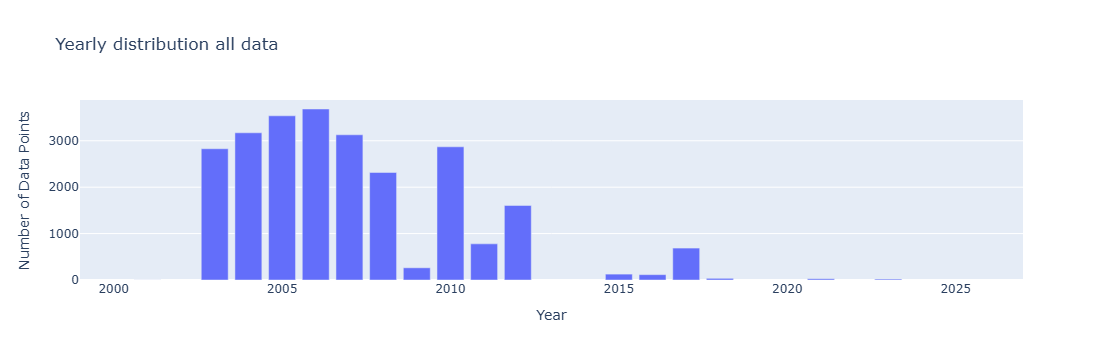

In [3]:
year_test=bco.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

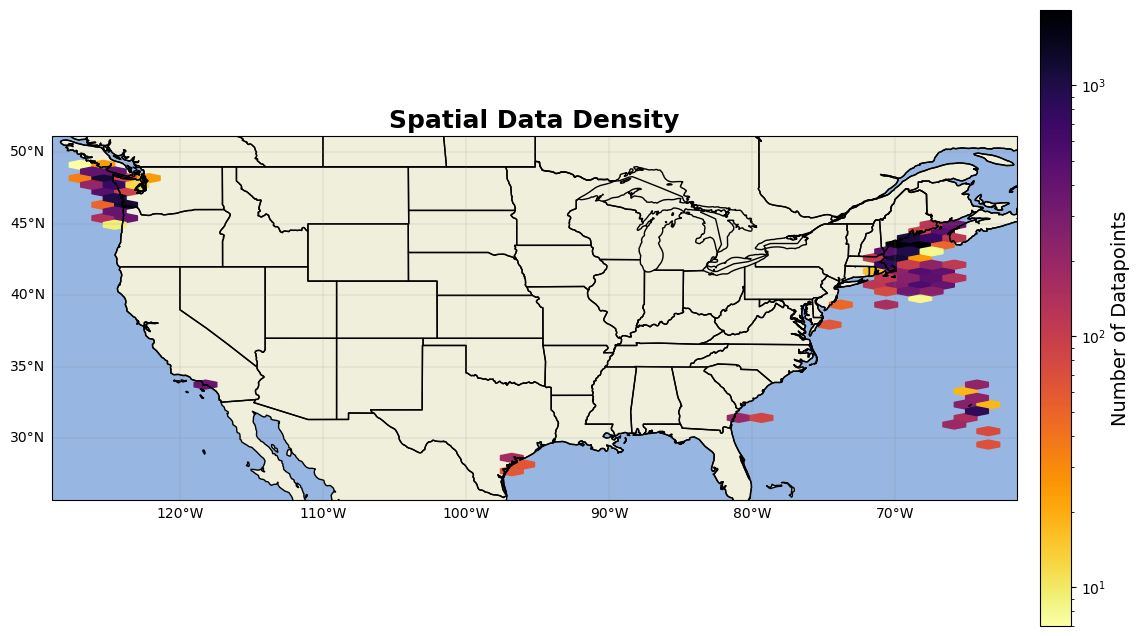

In [6]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=40, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()